<a href="https://colab.research.google.com/github/Malvocado/Machine_Learing_Final_Project/blob/main/Linear_regression_attempt_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load csv dataset

In [ ]:
df = pd.read_csv('BMW_sales_asia_2022_2024.csv')

Check shape and head

In [ ]:
print(df.shape)
print(df.head())
print(f"\nFeature name: ", df.columns.tolist())

(1703, 11)
      Model  Year  Color Fuel_Type Transmission  Engine_Size_L  Mileage_KM  \
0  5 Series  2024   Blue  Electric       Manual            3.7      157789   
1        X6  2022  White  Electric       Manual            1.9      182027   
2        X5  2024   Blue    Hybrid    Automatic            2.6      120597   
3        M3  2022   Blue    Diesel       Manual            1.8      189688   
4        X3  2022  Black    Diesel       Manual            4.0      160878   

   Price_USD  Sales_Volume Sales_Classification  Years_Relative  
0      86855           648                  Low               0  
1      35951          3389                  Low               2  
2      95900          8581                 High               0  
3      38811          7337                 High               2  
4      53997          2162                  Low               2  

Feature name:  ['Model', 'Year', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_V

#Separate feature and target

In [ ]:
X = df[['Model', 'Years_Relative', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM']]
y = df['Price_USD']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (1703, 7)
Target (y) shape: (1703,)


,Model,Years_Relative,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM
0,5 Series,0,Blue,Electric,Manual,3.7,157789
1,X6,2,White,Electric,Manual,1.9,182027
2,X5,0,Blue,Hybrid,Automatic,2.6,120597
3,M3,2,Blue,Diesel,Manual,1.8,189688
4,X3,2,Black,Diesel,Manual,4.0,160878


,Price_USD
0,86855
1,35951
2,95900
3,38811
4,53997


# Train_test spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1362, 7)
X_test shape: (341, 7)
y_train shape: (1362,)
y_test shape: (341,)


### Scaling Numerical Features

We will use `StandardScaler` from `sklearn.preprocessing` to standardize the numerical features. This is an important preprocessing step as it ensures that no single feature dominates the model due to its scale.

In [ ]:
# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train numerical columns and transform both X_train and X_test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train numerical features after scaling:")
display(X_train[numerical_cols].head())
print("X_test numerical features after scaling:")
display(X_test[numerical_cols].head())

X_train numerical features after scaling:


,Years_Relative,Engine_Size_L,Mileage_KM
1196,1.223392,1.278135,-0.751813
422,1.223392,0.485863,-1.081291
1668,-1.184498,-0.603511,0.969394
575,0.019447,0.782965,-1.643773
548,1.223392,1.476203,-1.589622


X_test numerical features after scaling:


,Years_Relative,Engine_Size_L,Mileage_KM
1046,1.223392,1.476203,0.865665
745,-1.184498,-0.900613,1.141164
785,0.019447,0.287795,1.204855
367,0.019447,-0.009307,-0.622556
1029,-1.184498,-0.900613,0.690680


### Visualization of Scaled Numerical Features

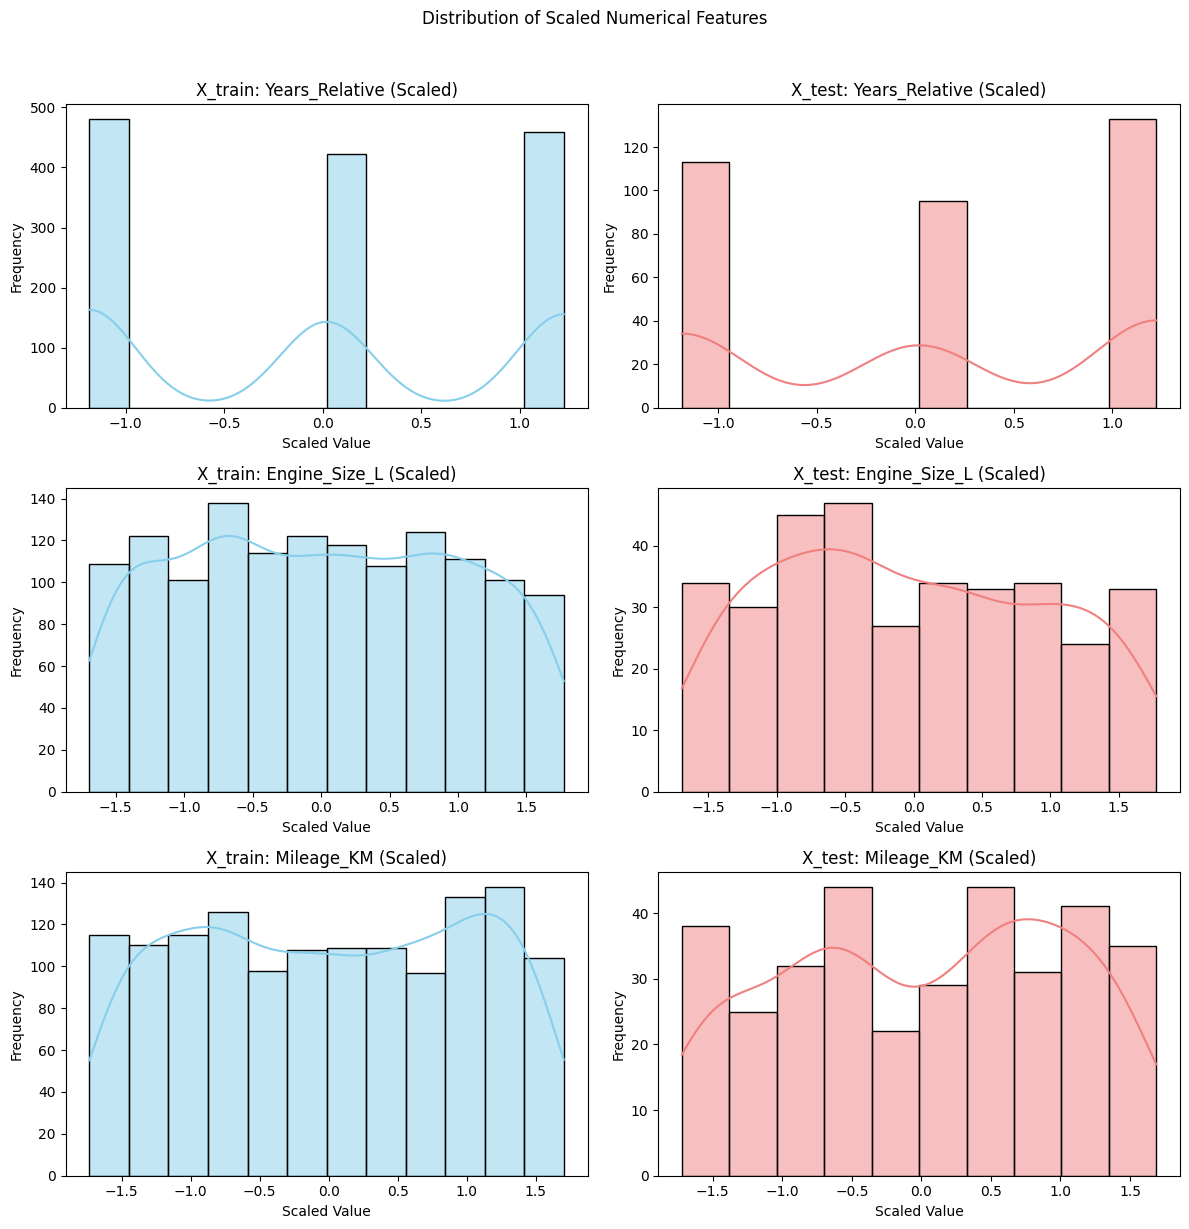

In [ ]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 4 * len(numerical_cols)))
fig.suptitle('Distribution of Scaled Numerical Features', y=1.02)

for i, col in enumerate(numerical_cols):
    # X_train distribution
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'X_train: {col} (Scaled)')
    axes[i, 0].set_xlabel('Scaled Value')
    axes[i, 0].set_ylabel('Frequency')

    # X_test distribution
    sns.histplot(X_test[col], kde=True, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'X_test: {col} (Scaled)')
    axes[i, 1].set_xlabel('Scaled Value')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### One-Hot Encoding Categorical Features

We will use `OneHotEncoder` from `sklearn.preprocessing` to convert categorical features into a one-hot encoded numerical array. This is necessary because most machine learning models cannot work directly with text labels.

In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Initialize OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on X_train categorical columns and transform both X_train and X_test
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_cols])

# Create DataFrame for encoded features
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate with encoded ones
X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_encoded_df], axis=1)

print("X_train after one-hot encoding:")
display(X_train.head())
print("X_test after one-hot encoding:")
display(X_test.head())

X_train after one-hot encoding:


,Years_Relative,Engine_Size_L,Mileage_KM,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
1196,1.223392,1.278135,-0.751813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
422,1.223392,0.485863,-1.081291,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1668,-1.184498,-0.603511,0.969394,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
575,0.019447,0.782965,-1.643773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
548,1.223392,1.476203,-1.589622,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


X_test after one-hot encoding:


,Years_Relative,Engine_Size_L,Mileage_KM,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
1046,1.223392,1.476203,0.865665,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
745,-1.184498,-0.900613,1.141164,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
785,0.019447,0.287795,1.204855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
367,0.019447,-0.009307,-0.622556,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1029,-1.184498,-0.900613,0.690680,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### Visualize Numerical Features vs. Price

Now, let's create scatter plots to see how each numerical feature relates to the target variable `Price_USD`. This helps in understanding potential correlations and patterns.

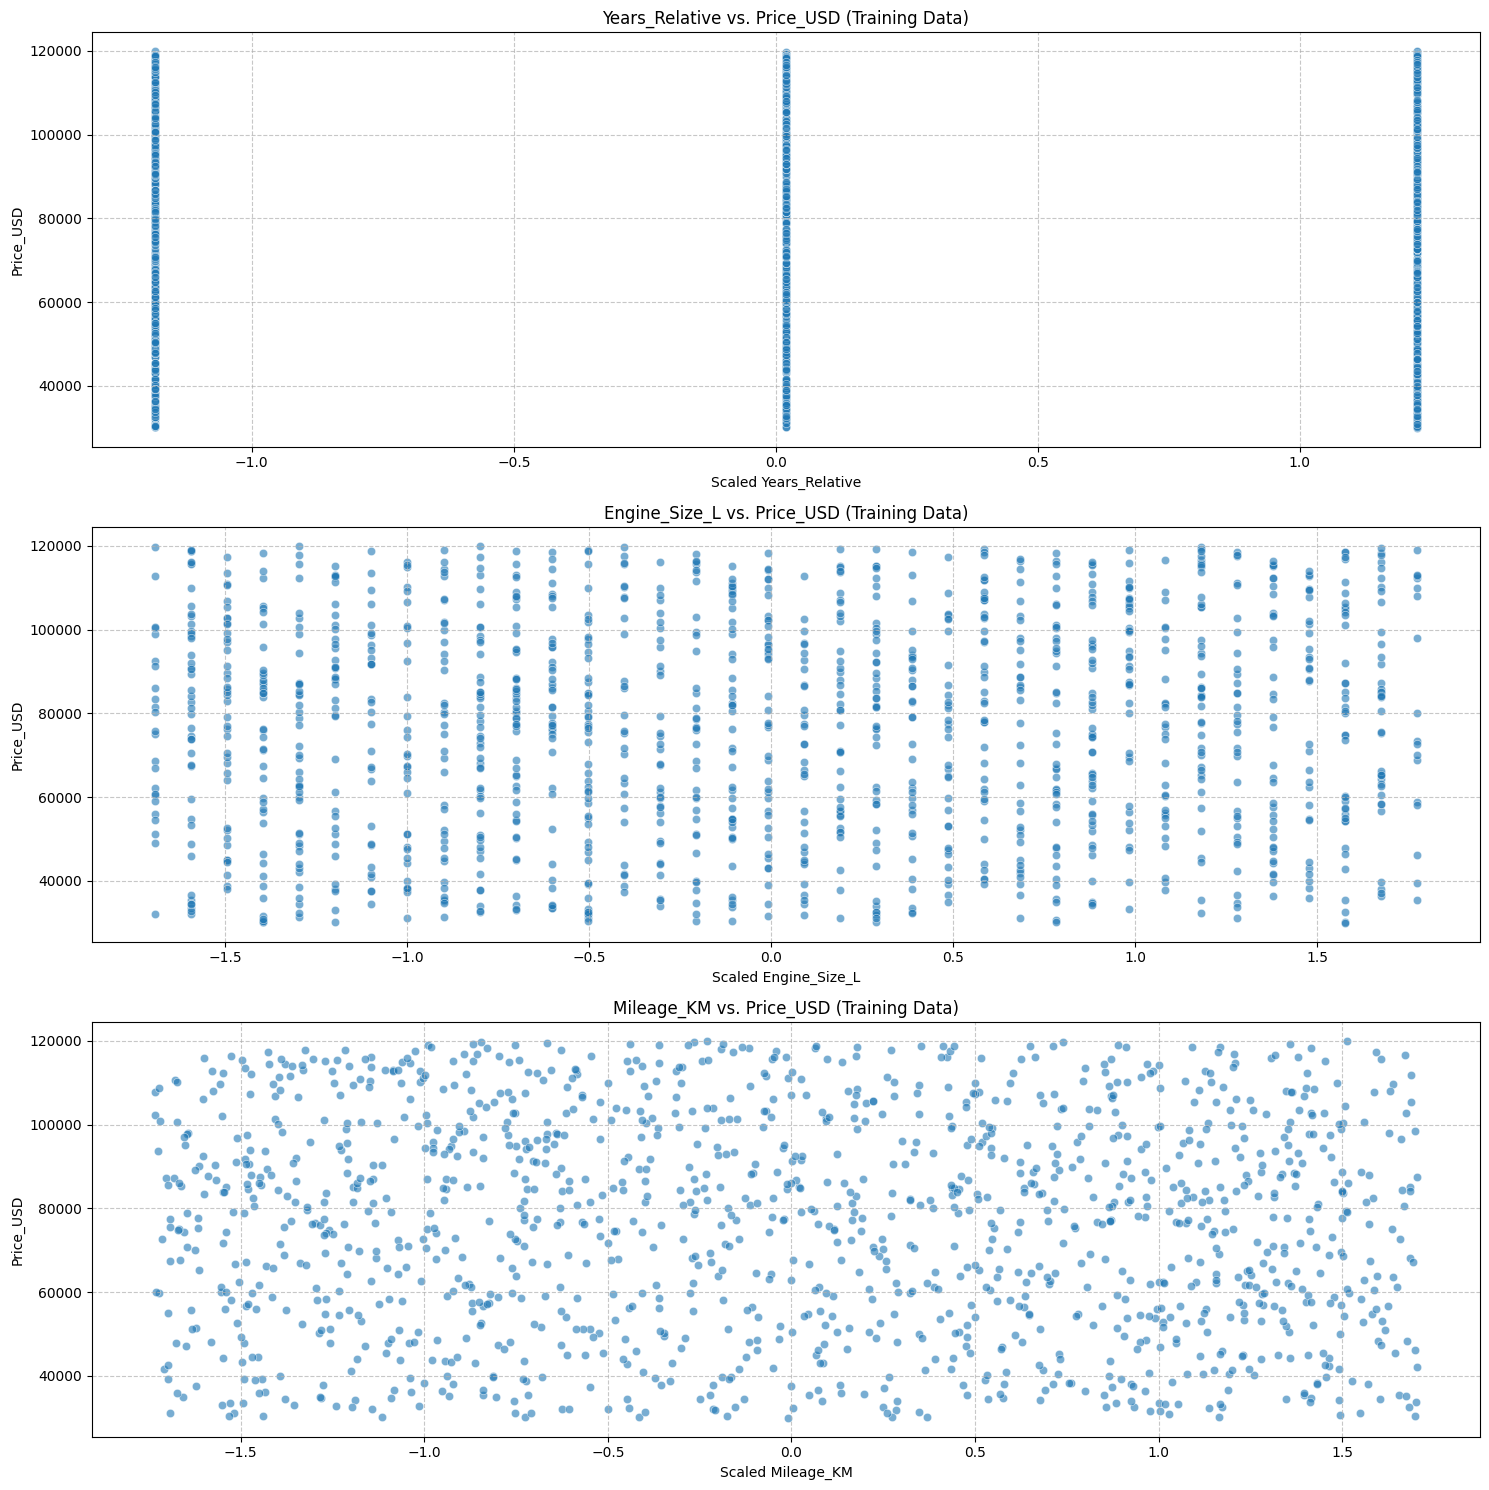

In [ ]:
plt.figure(figsize=(15, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.scatterplot(x=X_train[col], y=y_train, alpha=0.6)
    plt.title(f'{col} vs. Price_USD (Training Data)')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Price_USD')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Calculate Correlation Matrix

Let's calculate the correlation matrix between all features in `X_train` (including the one-hot encoded categorical features and scaled numerical features) and the target variable `Price_USD` (`y_train`). This will give us a quantitative measure of the linear relationship between each feature and the price.

In [ ]:
# Combine X_train and y_train into a single DataFrame to calculate correlations
train_df = pd.concat([X_train, y_train], axis=1)

# Calculate the correlation matrix
correlation_matrix = train_df.corr()

# Display the correlation of all features with 'Price_USD'
display(correlation_matrix['Price_USD'].sort_values(ascending=False))

,Price_USD
Price_USD,1.000000
Model_3 Series,0.058491
Transmission_Automatic,0.058288
Fuel_Type_Hybrid,0.044354
Engine_Size_L,0.043750
Model_7 Series,0.033216
Model_X6,0.028221
Fuel_Type_Petrol,0.016571
Model_X5,0.014905
Color_Red,0.012258


### Visualize Correlation Matrix

Let's visualize the correlation of all features with `Price_USD` using a heatmap. This provides a clear, color-coded representation of how each feature's change is associated with a change in the `Price_USD`.

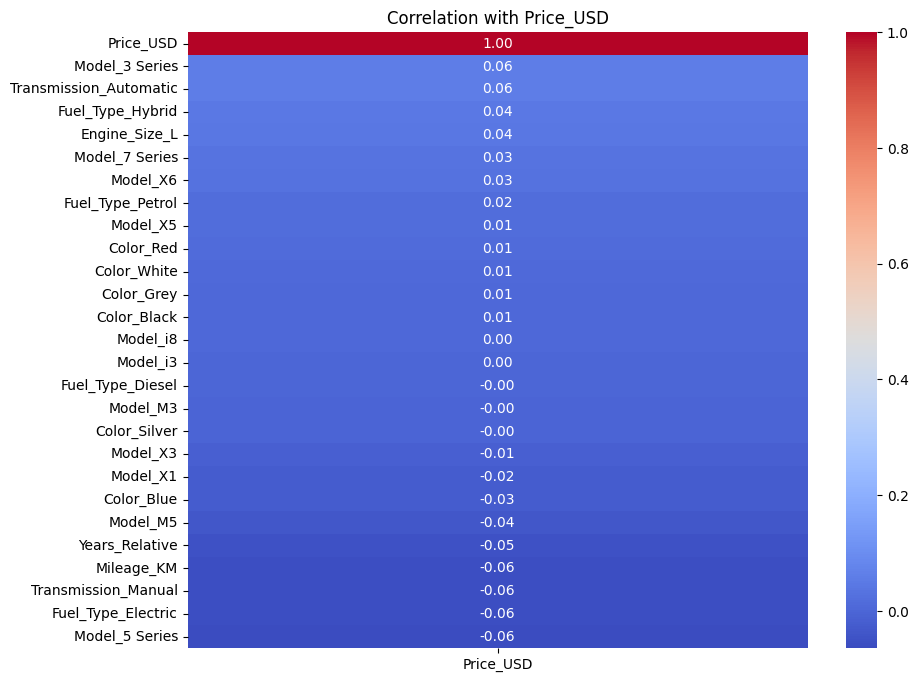

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['Price_USD']].sort_values(by='Price_USD', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Price_USD')
plt.show()

## Sooooo Without wasting any more time since the matrix clearly show that there is no linear relationship in this dataset. We will move to another algorithm.

# Thank you!